# Multiclass Car Classifier — Model Zoo

Math lives in `.py` files (`common/data.py`, `numpy_model/network.py`, `tf_model/model.py`, `sklearn_baseline/model.py`, `comparison/plots.py`). This notebook only runs checks and plots.

Run from the repo root. 7 classes, input `64×64×3` flattened to 12288 features.

# Phase 0 — Data pipeline

Load images, resize to 64×64, flatten, scale pixels to [0, 1], and split 70/15/15 stratified. Shared by every model so they train on the same arrays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from common.data import CLASS_NAMES, FLAT_DIM, load_dataset, to_one_hot
from numpy_model.network import (
    LAYER_DIMS,
    accuracy,
    backward,
    compute_loss,
    forward,
    init_params,
    train,
    update_params,
)

data = load_dataset()
for split in ("train", "val", "test"):
    X, y = data[f"X_{split}"], data[f"y_{split}"]
    print(f"{split:5}  X {X.shape}  y {y.shape}  range=[{X.min():.3f}, {X.max():.3f}]")
print("flat dim", FLAT_DIM, "classes", CLASS_NAMES)

train  X (5283, 12288)  y (5283,)  range=[0.000, 1.000]
val    X (1133, 12288)  y (1133,)  range=[0.000, 1.000]
test   X (1133, 12288)  y (1133,)  range=[0.000, 1.000]
flat dim 12288 classes ('Convertible', 'Coupe', 'Hatchback', 'Pick-Up', 'SUV', 'Sedan', 'VAN')


# Phase 1 — Forward pass

Random weights, one batch through `12288 → 128 → 64 → 7` (ReLU, ReLU, softmax). Check that the output is `(m, 7)` and each row sums to 1.

In [2]:
print("LAYER_DIMS", LAYER_DIMS)
Xb = data["X_train"][:32]
params = init_params()
for name, arr in params.items():
    print(f"{name:4} {arr.shape}")

A3, cache = forward(Xb, params)
print("A3", A3.shape, "row sums", A3.sum(axis=1)[:4], "...")
print("range", A3.min(), A3.max(), "cache", sorted(cache.keys()))

LAYER_DIMS [12288, 128, 64, 7]
W1   (12288, 128)
b1   (128,)
W2   (128, 64)
b2   (64,)
W3   (64, 7)
b3   (7,)
A3 (32, 7) row sums [1. 1. 1. 1.] ...
range 0.026071841042753122 0.4374293598522986 cache ['A1', 'A2', 'A3', 'X', 'Z1', 'Z2', 'Z3']


# Phase 2 — Backprop on a tiny subset

Cross-entropy loss, backward pass, and vanilla GD on 50 images. If loss does not fall here, the full dataset will not help.

step   0  loss 1.9519
step  20  loss 1.9346
step  40  loss 1.9195
step  60  loss 1.9113
step  79  loss 1.9069


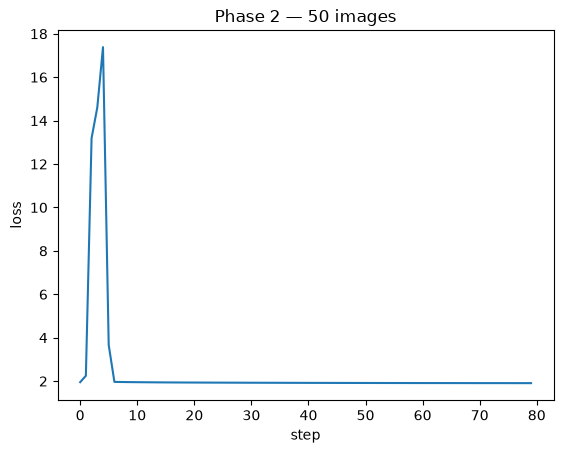

In [3]:
X_tiny = data["X_train"][:50]
Y_tiny = to_one_hot(data["y_train"][:50])
params = init_params()
losses = []
for step in range(80):
    A3, cache = forward(X_tiny, params)
    loss = compute_loss(A3, Y_tiny)
    grads = backward(A3, Y_tiny, cache, params)
    params = update_params(params, grads, learning_rate=0.1)
    losses.append(float(loss))
    if step % 20 == 0 or step == 79:
        print(f"step {step:3d}  loss {loss:.4f}")

plt.plot(losses)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Phase 2 — 50 images")
plt.show()

# Phase 3 — Full training and diagnosis

Mini-batch GD on the full train set. Plot train vs val loss, then accuracy. Diagnosis is in 3.3.

epoch   1/20  train 3.6582  val 1.9398
epoch   2/20  train 1.9414  val 1.9397
epoch   3/20  train 1.9412  val 1.9403
epoch   4/20  train 1.9416  val 1.9398
epoch   5/20  train 1.9413  val 1.9405
epoch   6/20  train 1.9416  val 1.9406
epoch   7/20  train 1.9417  val 1.9407
epoch   8/20  train 1.9407  val 1.9399
epoch   9/20  train 1.9413  val 1.9405
epoch  10/20  train 1.9420  val 1.9400
epoch  11/20  train 1.9421  val 1.9391
epoch  12/20  train 1.9414  val 1.9410
epoch  13/20  train 1.9421  val 1.9396
epoch  14/20  train 1.9415  val 1.9398
epoch  15/20  train 1.9414  val 1.9402
epoch  16/20  train 1.9416  val 1.9398
epoch  17/20  train 1.9411  val 1.9402
epoch  18/20  train 1.9411  val 1.9396
epoch  19/20  train 1.9410  val 1.9401
epoch  20/20  train 1.9419  val 1.9394


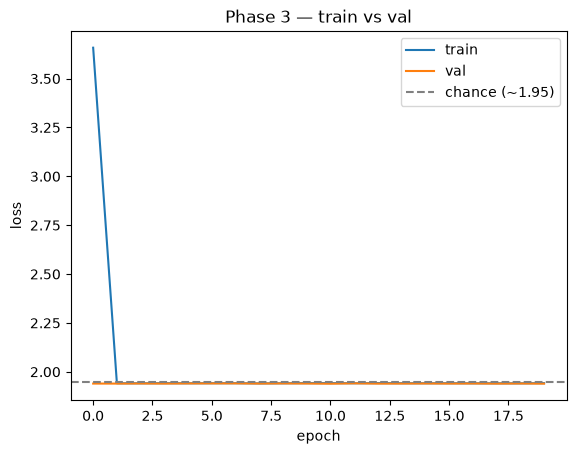

final train loss 1.9419  val 1.9394
train acc 0.169  val acc 0.169


In [4]:
Y_train = to_one_hot(data["y_train"])
Y_val = to_one_hot(data["y_val"])

params, history = train(
    data["X_train"], Y_train,
    data["X_val"], Y_val,
    epochs=20, batch_size=64, learning_rate=0.5,
)

plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.axhline(np.log(7), linestyle="--", color="gray", label="chance (~1.95)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Phase 3 — train vs val")
plt.show()

A_train, _ = forward(data["X_train"], params)
A_val, _ = forward(data["X_val"], params)
print(f"final train loss {history['train_loss'][-1]:.4f}  val {history['val_loss'][-1]:.4f}")
print(f"train acc {accuracy(A_train, data['y_train']):.3f}  val acc {accuracy(A_val, data['y_val']):.3f}")

## 3.3 Diagnosis

This is **high bias**, not high variance. Train and val loss both sit at ~1.94 (chance is 1.95) with almost no gap, and both accuracies are 16.9%. That is not a memorizer (those have low train error and high val error). The net never fits the training set.

16.9% is also the share of the majority class (Convertible), not a fair 7-way guess (~14.3%). After epoch 1 the loss stops moving: the model is stuck predicting like a constant/majority classifier.

**Next:** raise the learning rate (or train longer) before changing the architecture — this may still be an optimizer problem. Regularization would be the wrong lever (that is for variance). If train loss still cannot leave ~1.94, then the flattened 64×64 pixels are the ceiling: neighboring pixels are unrelated features, and a bigger net or a CNN would be the real fix.

# Phase 4 — TensorFlow / Keras

Same net as Phase 3 (`12288 → 128 → 64 → 7`, ReLU / ReLU / softmax), same arrays, same 20 epochs, batch 64, and **SGD at lr=0.5** (not Adam). Compare accuracy and wall time to the NumPy run, then say why they differ.

Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1533 - loss: 1286.1058 - val_accuracy: 0.1695 - val_loss: 1.9394
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1656 - loss: 1.9415 - val_accuracy: 0.1695 - val_loss: 1.9395
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1660 - loss: 1.9415 - val_accuracy: 0.1695 - val_loss: 1.9395
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1660 - loss: 1.9415 - val_accuracy: 0.1695 - val_loss: 1.9395
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1660 - loss: 1.9415 - val_accuracy: 0.1695 - val_loss: 1.9395
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1660 - loss: 1.9415 - val_accuracy: 0.1695 - val_loss: 1.9395
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1660 - loss: 1.9415 - val_accuracy: 0.1695 - val_loss: 1.9395
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1660 - loss: 1.9415 - val_accuracy: 0.1695 - val_lo

Model: "car_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,705 (6.03 MB)

 Trainable params: 1,581,703 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

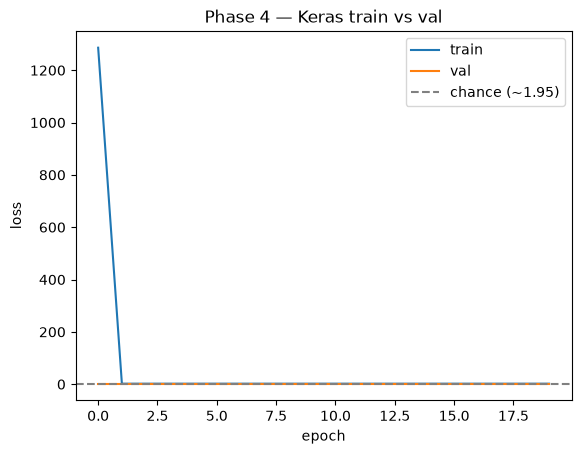

Keras  4.5s  train acc 0.166  val acc 0.169
       final train loss 1.9415  val 1.9395
NumPy  train loss 1.9419  val 1.9394


In [5]:
from tf_model.model import train as train_keras

if "data" not in dir():
    data = load_dataset()
if "Y_train" not in dir():
    Y_train = to_one_hot(data["y_train"])
    Y_val = to_one_hot(data["y_val"])

keras_model, keras_history, keras_seconds = train_keras(
    data["X_train"], Y_train,
    data["X_val"], Y_val,
    epochs=20, batch_size=64, learning_rate=0.5,
)
keras_model.summary()

plt.plot(keras_history["loss"], label="train")
plt.plot(keras_history["val_loss"], label="val")
plt.axhline(np.log(7), linestyle="--", color="gray", label="chance (~1.95)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Phase 4 — Keras train vs val")
plt.show()

print(f"Keras  {keras_seconds:.1f}s  train acc {keras_history['accuracy'][-1]:.3f}  val acc {keras_history['val_accuracy'][-1]:.3f}")
print(f"       final train loss {keras_history['loss'][-1]:.4f}  val {keras_history['val_loss'][-1]:.4f}")
if "history" in dir():
    print(f"NumPy  train loss {history['train_loss'][-1]:.4f}  val {history['val_loss'][-1]:.4f}")


## 4.3 Comparison

Same architecture, data, 20 epochs, batch 64, SGD lr=0.5.

| | train acc | val acc | train loss | val loss | wall time |
|---|---|---|---|---|---|
| NumPy SGD | 0.169 | 0.169 | 1.942 | 1.939 | minutes (not timed) |
| Keras SGD | 0.166 | 0.169 | 1.94 (after epoch 1) | 1.94 | **4.7s** |

Both sit on the **majority class (~17%)**. Keras epoch 1 train loss spiked to ~1286, then snapped to chance — same high-bias story as Phase 3, just much faster. The gap is **runtime**, not accuracy: Keras kernels vs NumPy + Python around your loops. Do not regularize these nets; they underfit. Phase 5 checks whether Adam or a linear model can move.

# Phase 5 — sklearn baseline

Third data point on the **same** arrays. Logistic regression is the linear sanity check (no hidden layers). `MLPClassifier` matches `128 → 64` hidden units but uses **Adam**, not the SGD lr=0.5 from Phases 3–4. Integer labels (`y`), not one-hot.

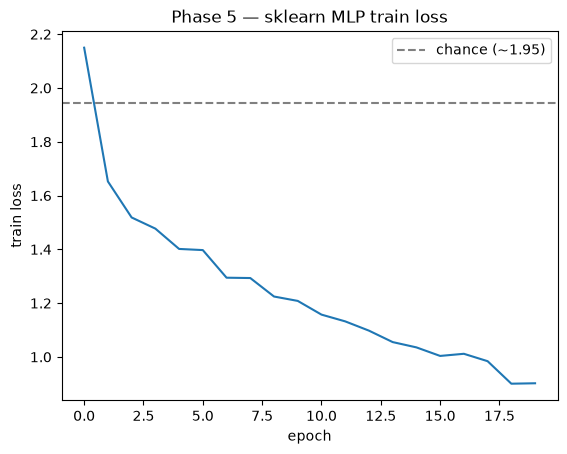

logreg  201.1s  train acc 0.982  val acc 0.500
MLP     15.1s  train acc 0.666  val acc 0.496
Keras   train acc 0.166  val acc 0.169


In [6]:
from sklearn_baseline.model import train_logreg, train_mlp

if "data" not in dir():
    data = load_dataset()

logreg, logreg_m, logreg_s = train_logreg(
    data["X_train"], data["y_train"],
    data["X_val"], data["y_val"],
)
mlp, mlp_m, mlp_s = train_mlp(
    data["X_train"], data["y_train"],
    data["X_val"], data["y_val"],
    epochs=20, batch_size=64,
)

plt.plot(mlp_m["loss_curve"])
plt.axhline(np.log(7), linestyle="--", color="gray", label="chance (~1.95)")
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.legend()
plt.title("Phase 5 — sklearn MLP train loss")
plt.show()

print(f"logreg  {logreg_s:.1f}s  train acc {logreg_m['train_acc']:.3f}  val acc {logreg_m['val_acc']:.3f}")
print(f"MLP     {mlp_s:.1f}s  train acc {mlp_m['train_acc']:.3f}  val acc {mlp_m['val_acc']:.3f}")
if "keras_history" in dir():
    print(f"Keras   train acc {keras_history['accuracy'][-1]:.3f}  val acc {keras_history['val_accuracy'][-1]:.3f}")


## 5.3 Comparison

Same arrays as Phases 3–4. Logistic regression uses integer `y` and saga (max_iter=200). sklearn MLP matches `128 → 64` but uses **Adam**.

| | train acc | val acc | wall time | diagnosis |
|---|---|---|---|---|
| NumPy / Keras SGD | ~0.17 | ~0.17 | Keras 4.7s | high bias (majority class) |
| logreg | **0.982** | **0.500** | 202.9s | high variance (12,288 features vs 5,283 rows) |
| sklearn MLP Adam | **0.666** | **0.496** | 16.8s | learns, then overfits some; 20 epochs not fully converged |

Logistic regression proves flattened pixels are **not** useless: a linear model memorizes train and still gets ~50% val (well above 17%). sklearn MLP with Adam leaves chance while SGD lr=0.5 did not — the stuck nets were the **optimizer / learning rate**, not “MLPs cannot classify cars.” Phase 6 plots this side by side.

# Phase 6 — Comparison and writeup

Uses models already in the kernel if you ran Phases 3–5. After a restart it trains anything missing (NumPy and logreg are the slow ones). Bars: train vs val accuracy and wall time. Overlay: loss (Keras epoch-1 spike is clipped). Confusion matrices: **val** set via `sklearn.metrics`.

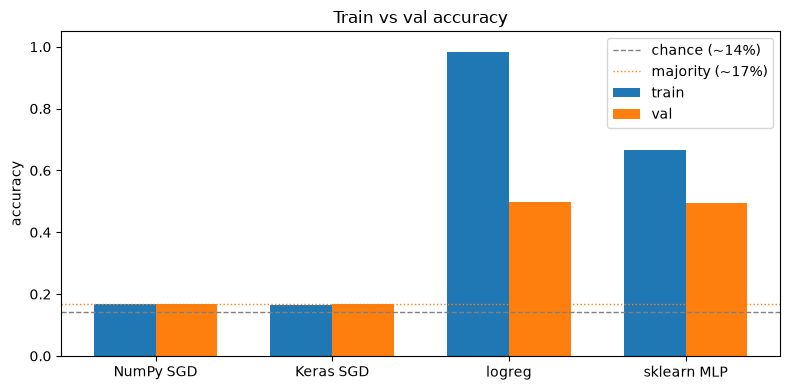

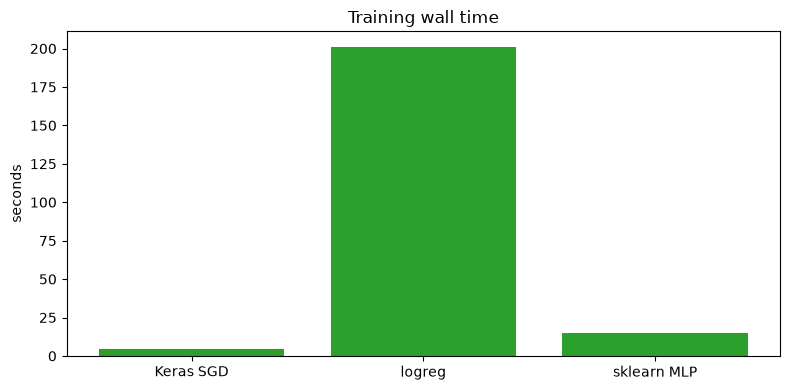

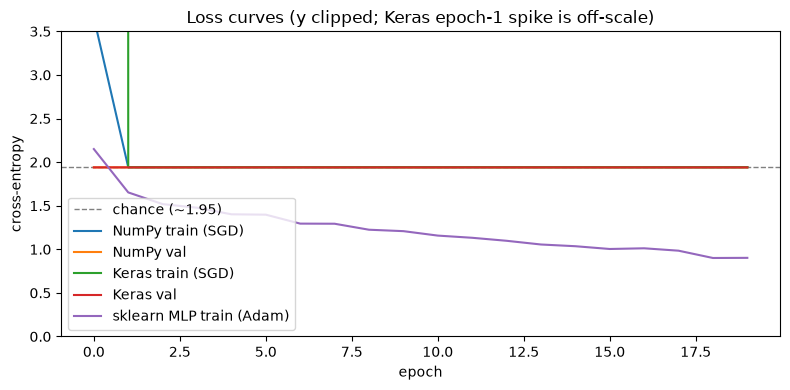

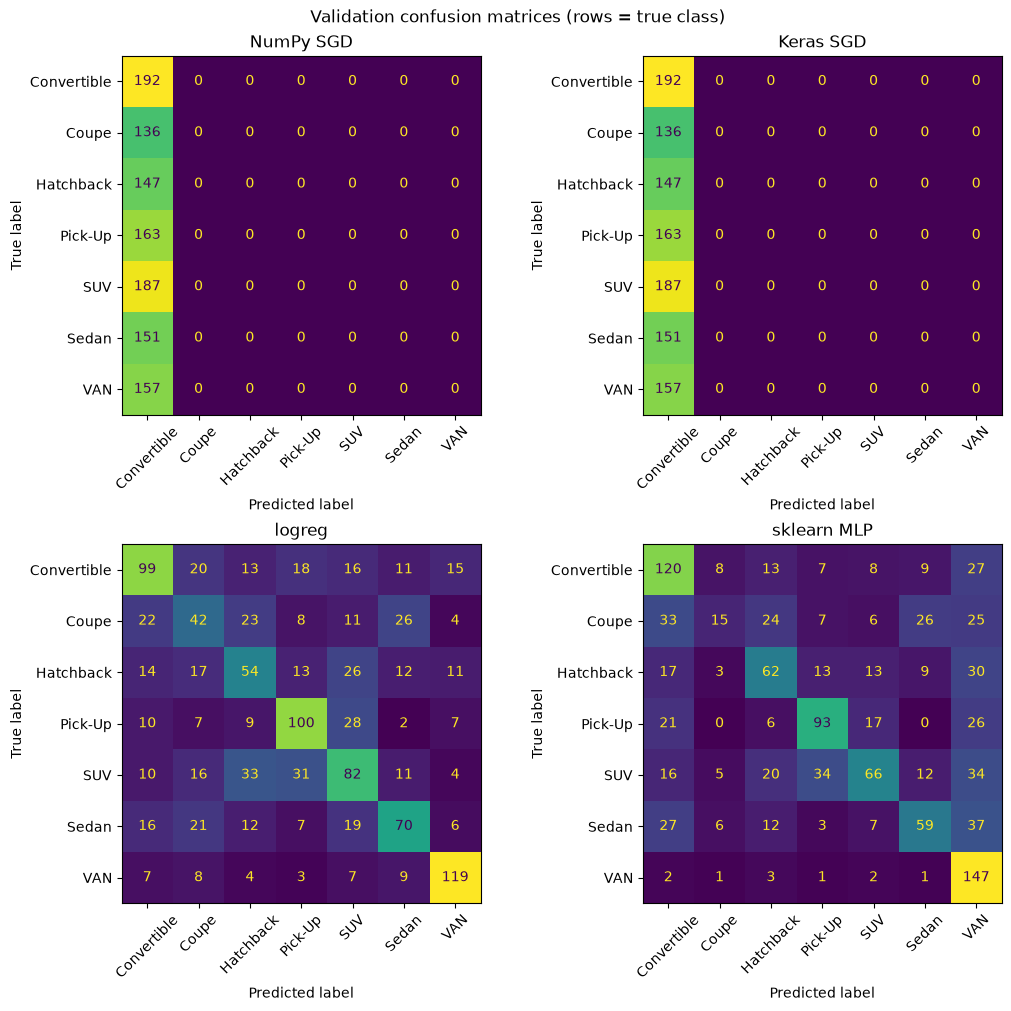

train / val accuracy
  NumPy SGD         0.169 / 0.169
  Keras SGD         0.166 / 0.169
  logreg            0.982 / 0.500
  sklearn MLP       0.666 / 0.496
times  Keras 4.5s  logreg 201.1s  MLP 15.1s  (NumPy not timed)
Keras epoch-1 train loss 1286.1 (off-scale on the overlay)


In [9]:
from common.data import load_dataset, to_one_hot
from comparison.plots import (
    plot_confusion_grid,
    plot_loss_overlay,
    plot_times,
    plot_train_val_acc,
)
from numpy_model.network import accuracy as numpy_accuracy
from numpy_model.network import forward
from numpy_model.network import train as train_numpy
from sklearn_baseline.model import train_logreg, train_mlp
from tf_model.model import train as train_keras

if "data" not in dir():
    data = load_dataset()
if "Y_train" not in dir():
    Y_train = to_one_hot(data["y_train"])
    Y_val = to_one_hot(data["y_val"])

if "history" not in dir() or "params" not in dir():
    print("NumPy not in kernel — training 20 epochs (a few minutes)...")
    params, history = train_numpy(
        data["X_train"], Y_train, data["X_val"], Y_val,
        epochs=20, batch_size=64, learning_rate=0.5,
    )
if "keras_model" not in dir() or "keras_history" not in dir() or "keras_seconds" not in dir():
    print("Keras not in kernel — training 20 epochs...")
    keras_model, keras_history, keras_seconds = train_keras(
        data["X_train"], Y_train, data["X_val"], Y_val,
        epochs=20, batch_size=64, learning_rate=0.5,
    )
if "logreg" not in dir() or "logreg_m" not in dir() or "logreg_s" not in dir():
    print("logreg not in kernel — fitting (a few minutes)...")
    logreg, logreg_m, logreg_s = train_logreg(
        data["X_train"], data["y_train"], data["X_val"], data["y_val"],
    )
if "mlp" not in dir() or "mlp_m" not in dir() or "mlp_s" not in dir():
    print("sklearn MLP not in kernel — training 20 epochs...")
    mlp, mlp_m, mlp_s = train_mlp(
        data["X_train"], data["y_train"], data["X_val"], data["y_val"],
        epochs=20, batch_size=64,
    )

y_train, y_val = data["y_train"], data["y_val"]
A3_tr, _ = forward(data["X_train"], params)
A3_va, _ = forward(data["X_val"], params)

numpy_train = float(numpy_accuracy(A3_tr, y_train))
numpy_val = float(numpy_accuracy(A3_va, y_val))
keras_train = float(keras_history["accuracy"][-1])
keras_val = float(keras_history["val_accuracy"][-1])

names = ["NumPy SGD", "Keras SGD", "logreg", "sklearn MLP"]
train_acc = [numpy_train, keras_train, logreg_m["train_acc"], mlp_m["train_acc"]]
val_acc = [numpy_val, keras_val, logreg_m["val_acc"], mlp_m["val_acc"]]

plot_train_val_acc(names, train_acc, val_acc)
plot_times(["Keras SGD", "logreg", "sklearn MLP"], [keras_seconds, logreg_s, mlp_s])
plot_loss_overlay(history, keras_history, mlp_m["loss_curve"])
plot_confusion_grid(
    y_val,
    {
        "NumPy SGD": np.argmax(A3_va, axis=1),
        "Keras SGD": keras_model.predict(data["X_val"], verbose=0).argmax(axis=1),
        "logreg": logreg.predict(data["X_val"]),
        "sklearn MLP": mlp.predict(data["X_val"]),
    },
)

print("train / val accuracy")
for n, t, v in zip(names, train_acc, val_acc):
    print(f"  {n:16s}  {t:.3f} / {v:.3f}")
print(f"times  Keras {keras_seconds:.1f}s  logreg {logreg_s:.1f}s  MLP {mlp_s:.1f}s  (NumPy not timed)")
print(f"Keras epoch-1 train loss {keras_history['loss'][0]:.1f} (off-scale on the overlay)")

## 6.3 What each model is good for, and what to try next

**NumPy SGD (hand-written).** Best for *you*: every `dZ`, `dW`, `db` is yours, so you can derive backprop on a whiteboard. Worst as a product: 20 epochs of lr=0.5 never left majority class (~17%). Benefit is the learning; the curve is a diagnosis, not a leaderboard score.

**Keras, same SGD.** Same high-bias result in **4.7s** instead of minutes. That is the point of the twin: if NumPy and Keras agree, the math is probably right and the *recipe* (flatten + SGD 0.5) is the bottleneck. Keras is the path you would actually iterate on (callbacks, GPU, later a CNN).

**Logistic regression.** Strongest *linear* story: train **98%**, val **50%**. With 12,288 features and 5,283 train rows the model can memorize train. Val at 50% still beats chance and majority — flattened pixels carry some signal. Cost: ~203s and a huge train/val gap (high variance). More L2 (smaller `C`), fewer features, or more data would be the bias/variance playbook — not a bigger net.

**sklearn MLP + Adam.** Same width/depth as NumPy/Keras, different optimizer. Train **67%**, val **50%**, 17s. Proves the 128→64 net *can* move; SGD lr=0.5 was the failure mode. Val matches logreg (~50%), so extra hidden layers on flattened pixels did not buy a better *generalization* ceiling here. 20 epochs had not fully converged.

### Why they diverge
- NumPy ≈ Keras because architecture, loss, and **SGD lr=0.5** match — both predict Convertible almost always.
- Logreg / Adam MLP leave chance because the optimizer (and, for logreg, the model class) is different — not because Keras “cheated.”
- Flattening throws away neighborhood structure (a wheel is a blob of pixels, not a local pattern). That is why ~50% val is a realistic MLP ceiling on this task and a CNN is the honest next architecture.

### Better for future improvements
1. **Do not** add dropout/L2 to the stuck SGD nets — they underfit.
2. **Do** try Adam or a much smaller SGD lr in NumPy/Keras (Phase 7 stretch) so the hand-written net can match sklearn’s learning.
3. **CNN** (or even a tiny conv stack) is the improvement that addresses the real ceiling: spatial features. Keep the same split and class names so the comparison stays fair.
4. Optional: 32×32 if CPU time hurts; stronger regularization or more data for logreg’s variance; **do not mine the test set** until the train/val story is the one you believe.
5. Test set stays held out. When you pick one story (likely: Adam MLP or a future CNN), evaluate test **once**.